In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
from prophet import Prophet
import numpy as np

C:\Users\GIBSON MZIMANDE\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Reading the csv with pandas**

In [5]:
df = pd.read_csv("Raw-sales-data.csv", encoding="ISO-8859-1")
pd.set_option("display.max_columns", None)

In [6]:
df.head(2)

,Invoice To Code,Invoice To Name,Sold To Code,Sold To Name,Document Number,Document Date,Document Fin Period,Document Type,Tax Code,Order Number,Customer Order Number,Order Date,Delivery Days,Planned Delivery Date,Item Class,Product Family,Item Number,Item Description,Sales Person,Supply Group,Quantity,Sales,Cost,Profit,Profit Percentage,Account,Delivery Line 1,Delivery Line 2,Delivery Line 3,Delivery Line 4,Delivery Line 5,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36,Unnamed: 37
0,001BT,BLOEM TECH (PTY) LTD,001BT,BLOEM TECH (PTY) LTD,INV-163657,4/30/2021,Apr-21,INVOICE,01A,SO-065395,QT-015097,4/28/2021,0.0,5/26/2021,SP,SP » SPARES,9927520010,PL.PR.FLUOR.TUBE COVER 1300MM,HOPE MHLONGO,NaN,6,410.7,10.98,399.72,97.3,2000020 CS » Sales-Spare Parts-Third Party,1 WATERMEYER STREET,HILTON,BLOEMFONTEIN,FREE STATE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,001BT,BLOEM TECH (PTY) LTD,001BT,BLOEM TECH (PTY) LTD,INV-163657,4/30/2021,Apr-21,INVOICE,01A,SO-065395,QT-015097,4/28/2021,0.0,5/26/2021,SP,SP » SPARES,9948003080,CAP END DIFFUSER,HOPE MHLONGO,NaN,12,58.08,28.54,29.54,50.9,2000020 CS » Sales-Spare Parts-Third Party,1 WATERMEYER STREET,HILTON,BLOEMFONTEIN,FREE STATE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Making sure the the columns are stored as intergers**

In [7]:
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["Quantity"] = df["Quantity"].fillna(0)
df["Quantity"] = df["Quantity"].astype(int)

**Making sure the the columns are stored as intergers (Sales)**

In [8]:
df["Sales"] = pd.to_numeric(df["Sales"], errors="coerce")
df["Sales"] = df["Sales"].fillna(0)
df["Sales"] = df["Sales"].astype(int)

**Taking the absolute values of the dependent variable (Quantity & Sales)**

In [9]:
df["Quantity"] = df["Quantity"].abs()
df["Sales"] = df["Sales"].abs()

In [10]:
df.head(3)

,Invoice To Code,Invoice To Name,Sold To Code,Sold To Name,Document Number,Document Date,Document Fin Period,Document Type,Tax Code,Order Number,Customer Order Number,Order Date,Delivery Days,Planned Delivery Date,Item Class,Product Family,Item Number,Item Description,Sales Person,Supply Group,Quantity,Sales,Cost,Profit,Profit Percentage,Account,Delivery Line 1,Delivery Line 2,Delivery Line 3,Delivery Line 4,Delivery Line 5,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36,Unnamed: 37
0,001BT,BLOEM TECH (PTY) LTD,001BT,BLOEM TECH (PTY) LTD,INV-163657,4/30/2021,Apr-21,INVOICE,01A,SO-065395,QT-015097,4/28/2021,0.0,5/26/2021,SP,SP » SPARES,9927520010,PL.PR.FLUOR.TUBE COVER 1300MM,HOPE MHLONGO,NaN,6,410,10.98,399.72,97.3,2000020 CS » Sales-Spare Parts-Third Party,1 WATERMEYER STREET,HILTON,BLOEMFONTEIN,FREE STATE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,001BT,BLOEM TECH (PTY) LTD,001BT,BLOEM TECH (PTY) LTD,INV-163657,4/30/2021,Apr-21,INVOICE,01A,SO-065395,QT-015097,4/28/2021,0.0,5/26/2021,SP,SP » SPARES,9948003080,CAP END DIFFUSER,HOPE MHLONGO,NaN,12,58,28.54,29.54,50.9,2000020 CS » Sales-Spare Parts-Third Party,1 WATERMEYER STREET,HILTON,BLOEMFONTEIN,FREE STATE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,001BT,BLOEM TECH (PTY) LTD,001BT,BLOEM TECH (PTY) LTD,INV-163663,5/3/2021,May-21,INVOICE,01A,SO-065406,BLT2601,5/3/2021,0.0,5/3/2021,SP,SP » SPARES,9947002950,"FAN HOUSING, TRAY HV362/36SD",HOPE MHLONGO,NaN,1,94,41.17,53.31,56.4,2000020 CS » Sales-Spare Parts-Third Party,1 WATERMEYER STREET,HILTON,BLOEMFONTEIN,FREE STATE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df = df[["Document Date", "Document Type", "Quantity", "Sales", "Item Description"]]

**Converting the date to datetime object with pandas**

In [12]:
df.loc[:, "Document Date"] = pd.to_datetime(df["Document Date"])

**Dropping all the N/A values**

In [13]:
df = df.dropna(subset=["Document Date"])
df = df.dropna(subset=["Quantity"])

**Sorting the date from oldest to newest**

In [14]:
df = df.sort_values(by="Document Date", ascending=True)

In [ ]:
plt.figure(figsize=(10, 5))

**Quantity bar graph**

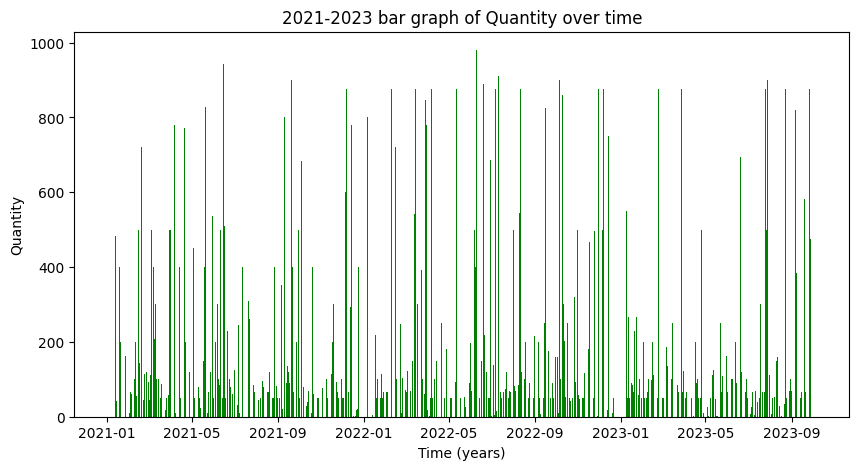

In [15]:
plt.figure(figsize=(10, 5))
plt.bar(df["Document Date"], df["Quantity"], color="green")
plt.title("2021-2023 bar graph of Quantity over time")
plt.xlabel("Time (years)")
plt.ylabel("Quantity")
plt.show()

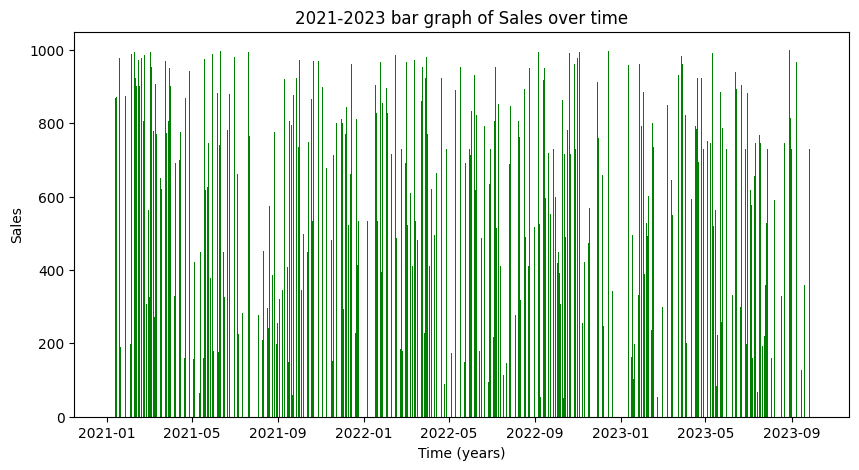

In [16]:
plt.figure(figsize=(10, 5))
plt.bar(df["Document Date"], df["Sales"], color="green")
plt.title("2021-2023 bar graph of Sales over time")
plt.xlabel("Time (years)")
plt.ylabel("Sales")
plt.show()

**Scatter Plot**

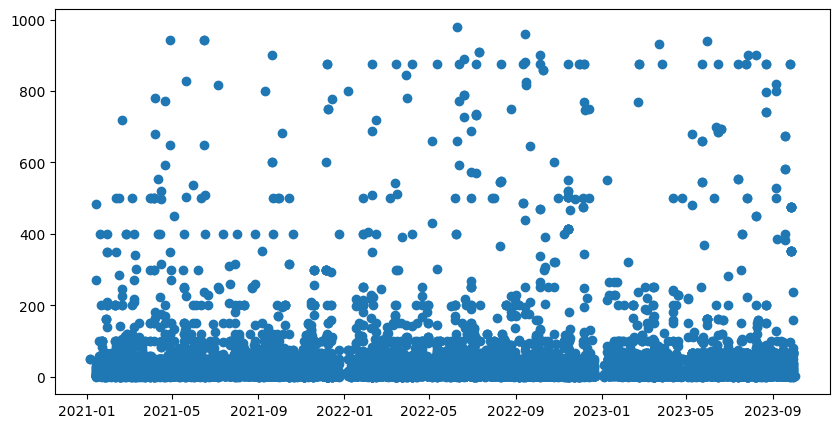

In [17]:
plt.figure(figsize=(10, 5))
plt.scatter(df["Document Date"], df["Quantity"])
plt.show()

**Coventing the dates to months**

In [19]:
df["Document Date"] = pd.to_datetime(df["Document Date"], errors="coerce", dayfirst=True)

In [20]:
df["Document Date"].dtypes

dtype('<M8[ns]')

In [21]:
df["Documnet Date"] = pd.to_datetime(df["Document Date"])
df["YearMonth"] = df["Document Date"].dt.to_period("M")

**Removing all the extra columnb and remaining with just date and quantity**

In [78]:
df_quantity = df[["Document Date", "Quantity"]]

**Renaming the columns according to prophet specifications (ns & y) and dropping N/A values**

In [57]:
df_quantity.columns = ["ds", "y"]
df_quantity = df_quantity.dropna(subset=["ds", "y"])
excel = df_quantity.to_csv("Cleaned Monthly data.csv")

**Importing Prophet object**

In [24]:
from prophet import Prophet

In [25]:
model_1 = Prophet()

In [26]:
model_1.fit(df_quantity)

00:23:28 - cmdstanpy - INFO - Chain [1] start processing
00:23:30 - cmdstanpy - INFO - Chain [1] done processing


**Making Future Predictions**

In [27]:
future_dates = model_1.make_future_dataframe(periods=365)

In [28]:
predictions = model_1.predict(future_dates)

In [56]:
predictions.head()
excel = predictions.to_csv("forecasted monthly sales (quantities).csv")

**Plotting Predictions**

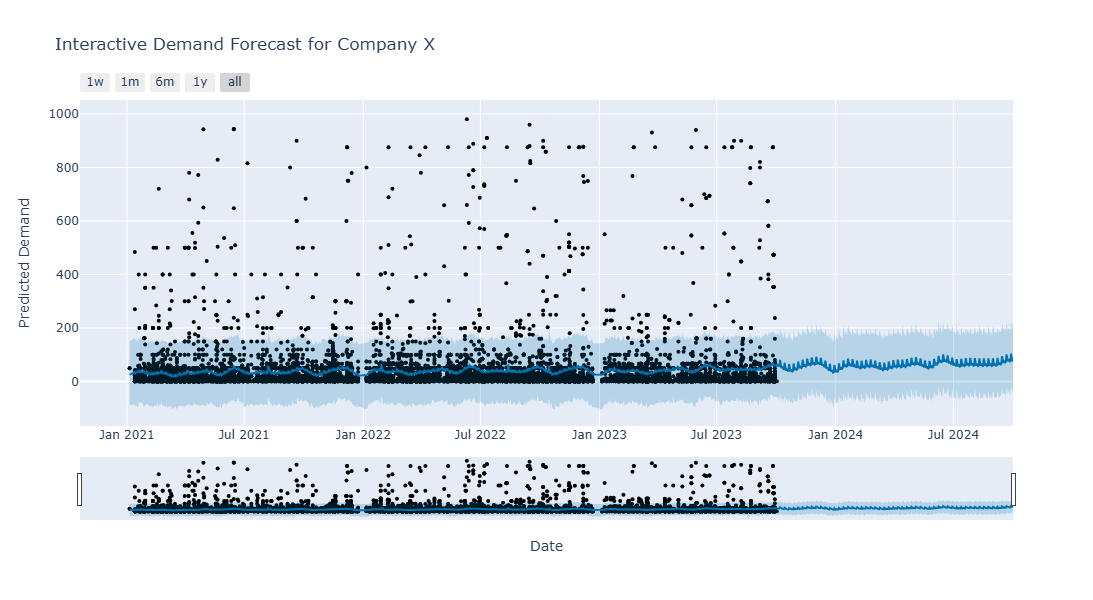

In [58]:
from prophet.plot import plot_plotly

fig = plot_plotly(model_1, predictions)
fig.update_layout(
    title="Interactive Demand Forecast for Company X",
    xaxis_title="Date",
    yaxis_title="Predicted Demand",
)
fig.show()


**Applying prophet on the sales data**

In [31]:
df_sales = df[["Document Date", "Sales"]]

In [32]:
df_sales.columns = ["ds", "y"]
df_sales = df_quantity.dropna(subset=["ds", "y"])

In [33]:
df_sales.head(2)

,ds,y
3173,2021-01-05,50
3295,2021-01-05,50


In [37]:
model_2 = Prophet()

In [39]:
model_2.fit(df_sales)

00:29:07 - cmdstanpy - INFO - Chain [1] start processing
00:29:08 - cmdstanpy - INFO - Chain [1] done processing


In [43]:
future_dates_2 = model_2.make_future_dataframe(periods=365)

In [44]:
future_sales = model_2.predict(future_dates_2)

In [54]:
future_sales.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2021-01-05,37.594858,-99.505784,139.407318,37.594858,37.594858,-11.834923,-11.834923,-11.834923,-0.075600,-0.075600,-0.075600,-11.759322,-11.759322,-11.759322,0.0,0.0,0.0,25.759935
1,2021-01-13,37.708239,-85.590544,148.190014,37.708239,37.708239,-3.426484,-3.426484,-3.426484,-3.850152,-3.850152,-3.850152,0.423668,0.423668,0.423668,0.0,0.0,0.0,34.281755
2,2021-01-14,37.722411,-90.898747,156.326965,37.722411,37.722411,-6.778832,-6.778832,-6.778832,-8.419141,-8.419141,-8.419141,1.640309,1.640309,1.640309,0.0,0.0,0.0,30.943579
3,2021-01-15,37.736584,-80.618909,152.911332,37.736584,37.736584,-4.012056,-4.012056,-4.012056,-6.716430,-6.716430,-6.716430,2.704374,2.704374,2.704374,0.0,0.0,0.0,33.724528
4,2021-01-18,37.779101,-81.801854,159.576115,37.779101,37.779101,-2.432098,-2.432098,-2.432098,-7.276686,-7.276686,-7.276686,4.844588,4.844588,4.844588,0.0,0.0,0.0,35.347003


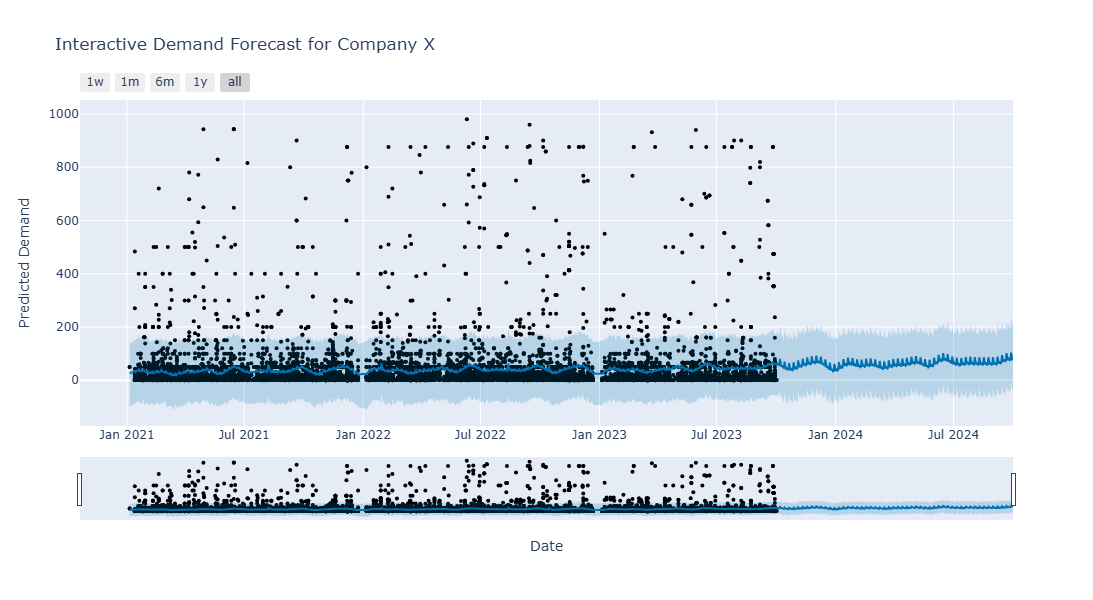

In [46]:
fig = plot_plotly(model_2, future_sales)
fig.update_layout(
    title="Interactive Demand Forecast for Company X",
    xaxis_title="Date",
    yaxis_title="Predicted Demand",
)
fig.show()

**Cross Validation**

In [49]:
from prophet.diagnostics import cross_validation

In [50]:
cv_df = cross_validation(model_2, initial="730 days", period="90 days", horizon="180 days")

  0%|                                                                     | 0/2 [00:00<?, ?it/s]16:45:21 - cmdstanpy - INFO - Chain [1] start processing
16:45:23 - cmdstanpy - INFO - Chain [1] done processing
 50%|██████████████████████████████▌                              | 1/2 [00:03<00:03,  3.51s/it]16:45:27 - cmdstanpy - INFO - Chain [1] start processing
16:45:28 - cmdstanpy - INFO - Chain [1] done processing
100%|█████████████████████████████████████████████████████████████| 2/2 [00:08<00:00,  4.38s/it]


In [51]:
cv_df.head()

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2023-01-09,32.801392,-78.167668,154.057662,216,2023-01-05
1,2023-01-09,32.801392,-85.590752,146.643787,85,2023-01-05
2,2023-01-09,32.801392,-88.179094,146.070321,550,2023-01-05
3,2023-01-09,32.801392,-81.862664,153.330115,70,2023-01-05
4,2023-01-09,32.801392,-90.524375,139.718411,10,2023-01-05


In [70]:
from prophet.diagnostics import performance_metrics

In [71]:
p_df = performance_metrics(cv_df)

In [59]:
excel = p_df.to_csv("Weekly performance metrics.csv")